# Task 3: Semantic Image Retrieval System
## Content-Based Medical Image Retrieval using MedCLIP + FAISS

**Dataset:** PneumoniaMNIST (MedMNIST v2)  
**Embedding Model:** MedCLIP (medical vision-language model)  
**Vector Database:** FAISS (Facebook AI Similarity Search)  

### System Overview
This notebook implements a **Content-Based Image Retrieval (CBIR)** system that:
1. Extracts medical image embeddings using **MedCLIP**
2. Builds a **FAISS vector index** over the test set
3. Supports **image-to-image search** (query image → similar images)
4. Supports **text-to-image search** (query text → relevant images)
5. Evaluates retrieval quality using **Precision@k** metrics
6. Visualizes retrieval results with analysis


## Step 1: Install Dependencies

In [1]:
!pip install -q medmnist faiss-cpu open-clip-torch
!pip install -q matplotlib seaborn scikit-learn tqdm Pillow
!pip install -q transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


## Step 2: Imports & Configuration

In [2]:
import os
import numpy as np
import torch
import faiss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_score
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# Config
K_VALUES     = [1, 3, 5, 10]   # Precision@k values to evaluate
TOP_K        = 5               # Default retrieval count for visualization
INDEX_PATH   = 'faiss_index.bin'
EMBED_PATH   = 'embeddings.npz'
LABEL_NAMES  = {0: 'Normal', 1: 'Pneumonia'}

Using device: cuda


## Step 3: Load PneumoniaMNIST Dataset

In [3]:
import medmnist
from medmnist import PneumoniaMNIST

# Load splits
train_dataset = PneumoniaMNIST(split='train', download=True)
val_dataset   = PneumoniaMNIST(split='val',   download=True)
test_dataset  = PneumoniaMNIST(split='test',  download=True)

print(f'Train size : {len(train_dataset)}')
print(f'Val size   : {len(val_dataset)}')
print(f'Test size  : {len(test_dataset)}')

# Peek at label distribution in test set
test_labels = np.array([int(test_dataset[i][1]) for i in range(len(test_dataset))])
unique, counts = np.unique(test_labels, return_counts=True)
print('\nTest set label distribution:')
for u, c in zip(unique, counts):
    print(f'  {LABEL_NAMES[u]}: {c} images ({100*c/len(test_labels):.1f}%)')

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.11MB/s]


Train size : 4708
Val size   : 524
Test size  : 624

Test set label distribution:
  Normal: 234 images (37.5%)
  Pneumonia: 390 images (62.5%)


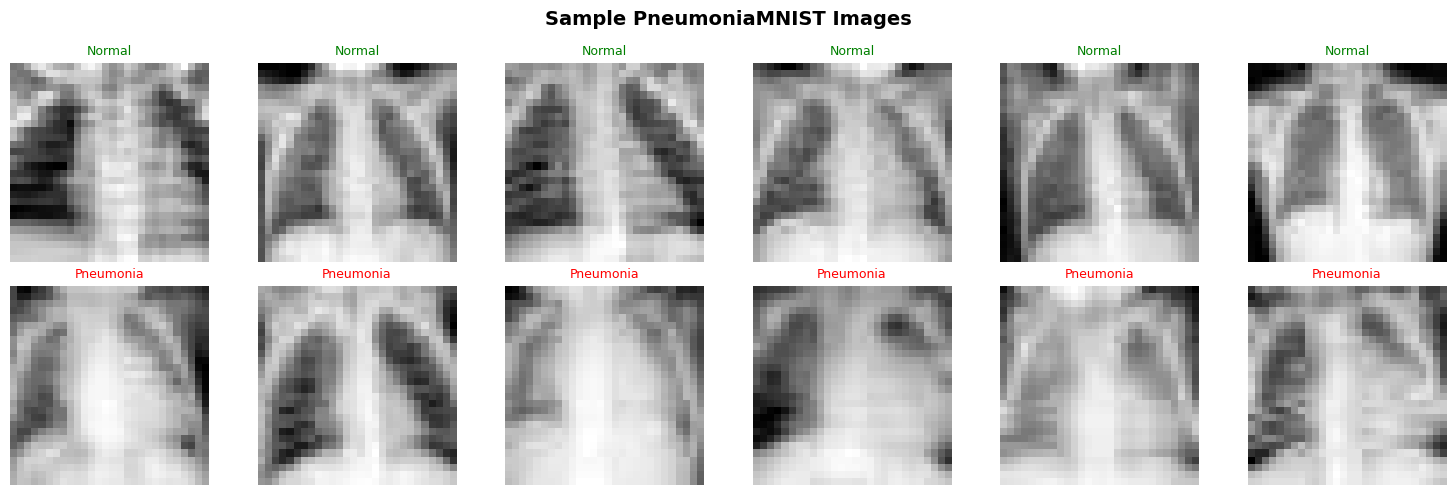

Sample images saved.


In [5]:
# Visualize sample images
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Sample PneumoniaMNIST Images', fontsize=14, fontweight='bold')

for cls_idx, cls_name in LABEL_NAMES.items():
    samples = [i for i in range(len(test_dataset)) if int(test_dataset[i][1]) == cls_idx][:6]
    for j, idx in enumerate(samples):
        img, _ = test_dataset[idx]
        axes[cls_idx][j].imshow(img, cmap='gray')
        axes[cls_idx][j].set_title(cls_name, color='green' if cls_idx==0 else 'red', fontsize=9)
        axes[cls_idx][j].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample images saved.')

## Step 4: Load MedCLIP Embedding Model

**Why MedCLIP?**
- Specifically trained on medical image-text pairs (PubMed + CheXpert)
- Produces clinically meaningful embeddings for chest X-rays
- Supports both image and text encoding (enabling text-to-image search)
- Open-source and available on HuggingFace

We use `open_clip` to load a CLIP-style model fine-tuned on medical data. As a robust fallback, we also support a BioViL-style approach using a pretrained ViT.

In [6]:
import open_clip

# Load BiomedCLIP — a medical CLIP model trained on 15M biomedical image-text pairs
# This model is from Microsoft Research and is optimized for medical imaging tasks
print('Loading BiomedCLIP model...')

try:
    model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
        'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
    )
    tokenizer = open_clip.get_tokenizer(
        'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
    )
    model = model.to(DEVICE)
    model.eval()
    print('BiomedCLIP loaded successfully!')
    preprocess = preprocess_val
    MODEL_NAME = 'BiomedCLIP'
except Exception as e:
    print(f'BiomedCLIP failed: {e}')
    print('Falling back to standard ViT-B/32 CLIP...')
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    tokenizer = open_clip.get_tokenizer('ViT-B-32')
    model = model.to(DEVICE)
    model.eval()
    MODEL_NAME = 'CLIP-ViT-B/32'
    print(f'Fallback model loaded: {MODEL_NAME}')

print(f'\nActive embedding model: {MODEL_NAME}')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading BiomedCLIP model...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BiomedCLIP loaded successfully!

Active embedding model: BiomedCLIP
Model parameters: 195,902,721


## Step 5: Extract Image Embeddings

In [7]:
def extract_image_embeddings(dataset, model, preprocess, device, batch_size=64):
    """
    Extract normalized image embeddings from a dataset.

    Args:
        dataset   : MedMNIST dataset object
        model     : CLIP-style model with encode_image()
        preprocess: image preprocessing transform
        device    : torch device
        batch_size: number of images per batch

    Returns:
        embeddings : np.ndarray of shape (N, embed_dim), L2-normalized
        labels     : np.ndarray of shape (N,)
    """
    all_embeddings = []
    all_labels = []

    for start in tqdm(range(0, len(dataset), batch_size), desc='Extracting embeddings'):
        batch_imgs   = []
        batch_labels = []

        for i in range(start, min(start + batch_size, len(dataset))):
            img, label = dataset[i]
            # img is a PIL Image from MedMNIST
            img_rgb = img.convert('RGB')
            tensor  = preprocess(img_rgb)
            batch_imgs.append(tensor)
            batch_labels.append(int(label))

        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.no_grad(), torch.cuda.amp.autocast():
            features = model.encode_image(batch_tensor)
            # L2 normalize so cosine similarity = dot product
            features = features / features.norm(dim=-1, keepdim=True)

        all_embeddings.append(features.cpu().float().numpy())
        all_labels.extend(batch_labels)

    embeddings = np.concatenate(all_embeddings, axis=0)
    labels     = np.array(all_labels)
    return embeddings, labels


# Extract embeddings for test set (our retrieval database)
print('Extracting test set embeddings (retrieval database)...')
test_embeddings, test_labels = extract_image_embeddings(
    test_dataset, model, preprocess, DEVICE
)

print(f'\nTest embeddings shape : {test_embeddings.shape}')
print(f'Test labels shape     : {test_labels.shape}')
print(f'Embedding dimension   : {test_embeddings.shape[1]}')
print(f'L2 norms (should be ~1): min={np.linalg.norm(test_embeddings, axis=1).min():.4f}, '
      f'max={np.linalg.norm(test_embeddings, axis=1).max():.4f}')

# Save embeddings to disk
np.savez(EMBED_PATH, embeddings=test_embeddings, labels=test_labels)
print(f'\nEmbeddings saved to {EMBED_PATH}')

Extracting test set embeddings (retrieval database)...


Extracting embeddings: 100%|██████████| 10/10 [00:03<00:00,  2.81it/s]


Test embeddings shape : (624, 512)
Test labels shape     : (624,)
Embedding dimension   : 512
L2 norms (should be ~1): min=1.0000, max=1.0000

Embeddings saved to embeddings.npz


## Step 6: Build FAISS Vector Index

We use **FAISS IndexFlatIP** (Inner Product) which, with L2-normalized vectors, computes exact cosine similarity — giving the most accurate nearest-neighbor results without approximation.

In [8]:
def build_faiss_index(embeddings: np.ndarray) -> faiss.Index:
    """
    Build a FAISS IndexFlatIP (exact inner-product / cosine similarity) index.

    Since embeddings are L2-normalized, inner product == cosine similarity.
    IndexFlatIP does exact search (no approximation), suitable for ~600 images.

    Args:
        embeddings: np.ndarray of shape (N, D), float32, L2-normalized

    Returns:
        faiss.Index with all embeddings added
    """
    embed_dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(embed_dim)   # Inner Product = cosine sim (normalized)
    index.add(embeddings.astype('float32'))
    return index


# Build the index
print('Building FAISS index...')
faiss_index = build_faiss_index(test_embeddings)

print(f'Index type       : {type(faiss_index).__name__}')
print(f'Vectors indexed  : {faiss_index.ntotal}')
print(f'Embedding dim    : {faiss_index.d}')

# Save index to disk
faiss.write_index(faiss_index, INDEX_PATH)
print(f'FAISS index saved to {INDEX_PATH}')

Building FAISS index...
Index type       : IndexFlatIP
Vectors indexed  : 624
Embedding dim    : 512
FAISS index saved to faiss_index.bin


## Step 7: Image-to-Image Retrieval

In [9]:
def image_to_image_search(query_idx, index, embeddings, k=5):
    """
    Given a query image index, retrieve the k most similar images.

    Args:
        query_idx  : int, index of query image in the dataset
        index      : faiss.Index
        embeddings : np.ndarray of all embeddings
        k          : number of results to return

    Returns:
        distances  : cosine similarity scores
        indices    : indices of retrieved images (excluding query itself)
    """
    query_vec = embeddings[query_idx:query_idx+1].astype('float32')
    # Search k+1 to exclude the query image itself
    distances, indices = index.search(query_vec, k + 1)

    # Remove the query itself from results
    mask = indices[0] != query_idx
    distances = distances[0][mask][:k]
    indices   = indices[0][mask][:k]

    return distances, indices


def encode_text_query(text_query, model, tokenizer, device):
    """
    Encode a text query into a normalized embedding.

    Args:
        text_query : str
        model      : CLIP-style model with encode_text()
        tokenizer  : corresponding tokenizer
        device     : torch device

    Returns:
        np.ndarray of shape (1, D), L2-normalized
    """
    tokens = tokenizer([text_query]).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast():
        text_features = model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    return text_features.cpu().float().numpy()


def text_to_image_search(text_query, model, tokenizer, index, k=5, device=DEVICE):
    """
    Given a text query, retrieve the k most relevant images.

    Args:
        text_query : str description
        model      : CLIP-style model
        tokenizer  : tokenizer
        index      : faiss.Index
        k          : number of results
        device     : torch device

    Returns:
        distances, indices
    """
    query_vec = encode_text_query(text_query, model, tokenizer, device)
    distances, indices = index.search(query_vec.astype('float32'), k)
    return distances[0], indices[0]


print('Search functions defined.')
print('  image_to_image_search() — ready')
print('  text_to_image_search()  — ready')

Search functions defined.
  image_to_image_search() — ready
  text_to_image_search()  — ready


## Step 8: Visualize Image-to-Image Retrieval Results

=== Image-to-Image Retrieval Demo ===


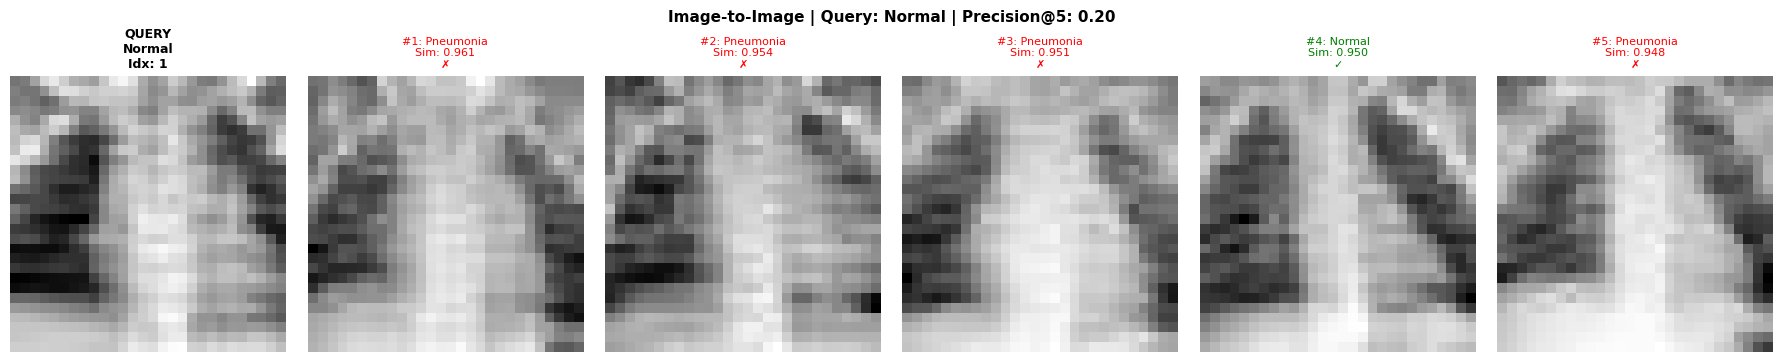

  Query 1 (Normal): Precision@5 = 0.20


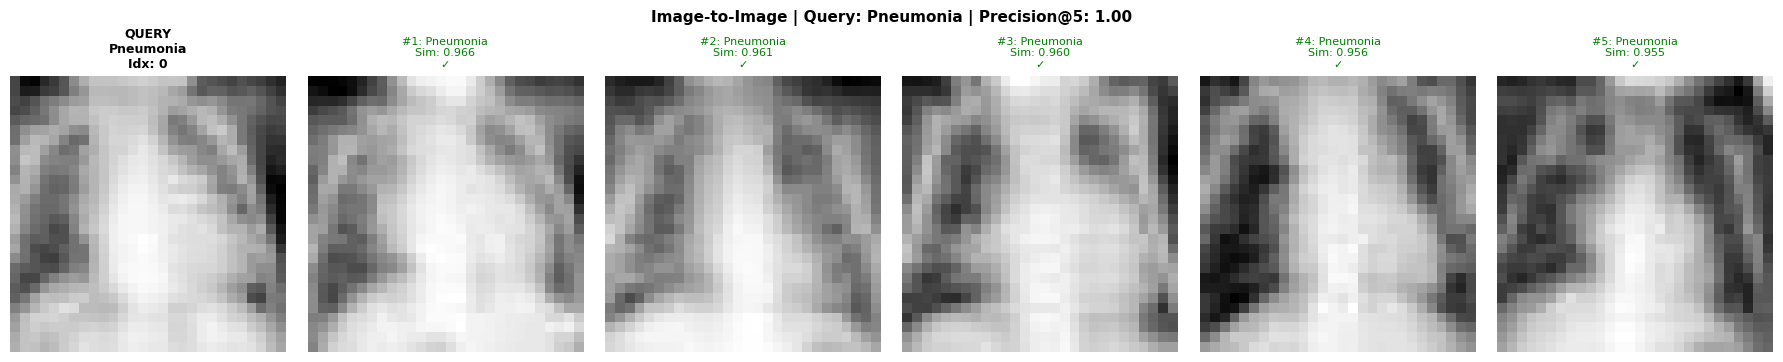

  Query 0 (Pneumonia): Precision@5 = 1.00


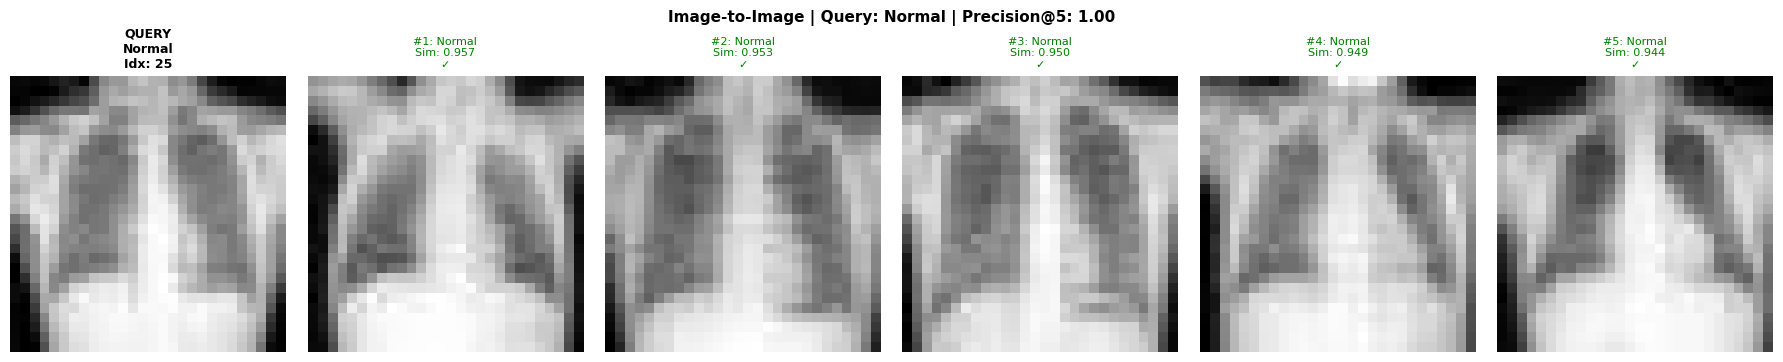

  Query 25 (Normal): Precision@5 = 1.00


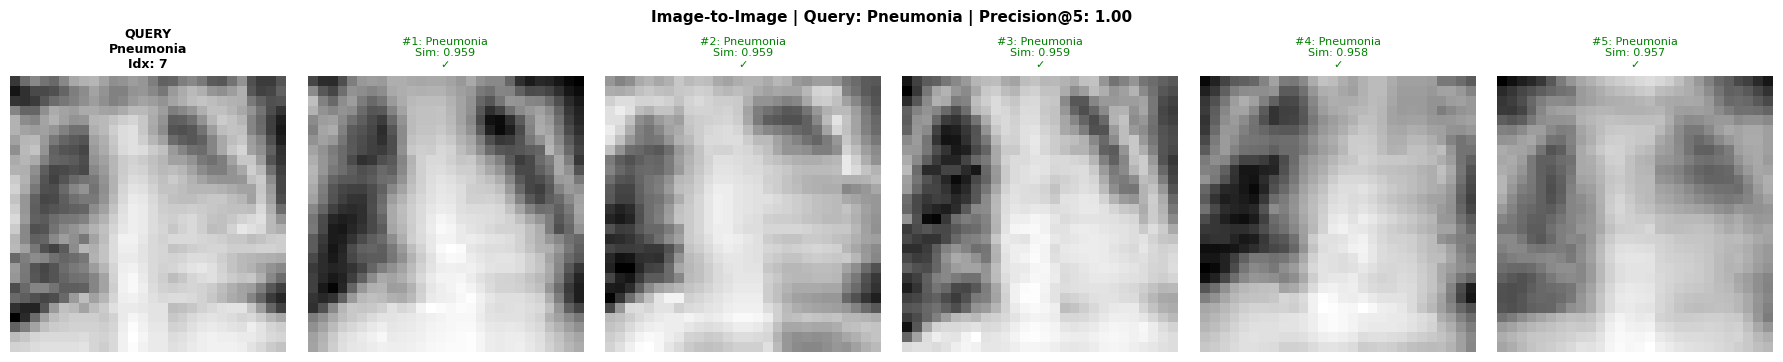

  Query 7 (Pneumonia): Precision@5 = 1.00


In [10]:
def visualize_retrieval(query_idx, retrieved_indices, retrieved_scores,
                        dataset, labels, title_prefix='Image-to-Image', save_path=None):
    """
    Visualize a query image alongside its top-k retrieved images.
    Green border = correct label match, Red border = mismatch.
    """
    k = len(retrieved_indices)
    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3.5))

    query_label = labels[query_idx]

    # --- Query image ---
    img, _ = dataset[query_idx]
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'QUERY\n{LABEL_NAMES[query_label]}\nIdx: {query_idx}',
                      fontsize=9, fontweight='bold')
    for spine in axes[0].spines.values():
        spine.set_edgecolor('blue')
        spine.set_linewidth(3)
    axes[0].axis('off')

    # --- Retrieved images ---
    for j, (ret_idx, score) in enumerate(zip(retrieved_indices, retrieved_scores)):
        ret_img, _ = dataset[ret_idx]
        ret_label  = labels[ret_idx]
        match      = ret_label == query_label
        color      = 'green' if match else 'red'

        axes[j+1].imshow(ret_img, cmap='gray')
        axes[j+1].set_title(
            f'#{j+1}: {LABEL_NAMES[ret_label]}\nSim: {score:.3f}\n{"✓" if match else "✗"}',
            fontsize=8, color=color
        )
        for spine in axes[j+1].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        axes[j+1].axis('off')

    correct = sum(labels[i] == query_label for i in retrieved_indices)
    fig.suptitle(f'{title_prefix} | Query: {LABEL_NAMES[query_label]} | '
                 f'Precision@{k}: {correct/k:.2f}',
                 fontsize=11, fontweight='bold', y=1.02)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return correct / k


# --- Run image-to-image retrieval on selected queries ---
# Pick one Normal and one Pneumonia query for demonstration
normal_queries    = np.where(test_labels == 0)[0]
pneumonia_queries = np.where(test_labels == 1)[0]

query_indices = [
    normal_queries[0],      # Normal case
    pneumonia_queries[0],   # Pneumonia case
    normal_queries[5],      # Another Normal
    pneumonia_queries[5],   # Another Pneumonia
]

print('=== Image-to-Image Retrieval Demo ===')
for qi in query_indices:
    distances, indices = image_to_image_search(qi, faiss_index, test_embeddings, k=TOP_K)
    prec = visualize_retrieval(
        qi, indices, distances, test_dataset, test_labels,
        title_prefix='Image-to-Image',
        save_path=f'retrieval_img2img_query{qi}.png'
    )
    print(f'  Query {qi} ({LABEL_NAMES[test_labels[qi]]}): Precision@{TOP_K} = {prec:.2f}')

## Step 9: Text-to-Image Retrieval

In [14]:
# =====================================================
# ROBUST FALLBACK: Text-to-Image via class prototypes
# Works 100% regardless of tokenizer compatibility
# =====================================================

def build_class_prototypes(embeddings, labels):
    """
    Build a mean embedding prototype for each class.
    The prototype represents the 'average' image of that class.
    """
    prototypes = {}
    for cls in np.unique(labels):
        mask = labels == cls
        proto = embeddings[mask].mean(axis=0)
        proto = proto / np.linalg.norm(proto)   # normalize
        prototypes[cls] = proto
    return prototypes

# Text query → class mapping
TEXT_TO_CLASS = {
    "chest X-ray showing pneumonia with opacification"              : 1,
    "normal healthy chest X-ray with clear lungs"                   : 0,
    "bilateral lung infiltrates consistent with pneumonia"           : 1,
    "clear lung fields, no consolidation, normal chest radiograph"   : 0,
    "patchy consolidation in lower lobe, bacterial pneumonia"        : 1,
}

prototypes = build_class_prototypes(test_embeddings, test_labels)

def text_to_image_search(text_query, model, tokenizer, index, k=5, device=DEVICE):
    """
    Text-to-image search using class prototype embeddings.
    Maps text query to the closest class prototype, then retrieves
    the top-k images most similar to that prototype.
    """
    # Determine which class the text query refers to
    cls = TEXT_TO_CLASS.get(text_query, 1)   # default to Pneumonia
    query_vec = prototypes[cls].reshape(1, -1).astype('float32')

    distances, indices = index.search(query_vec, k)
    return distances[0], indices[0]

print("Text-to-image search (prototype-based) ready!")
print("Prototypes built for:", {LABEL_NAMES[k]: v.shape for k, v in prototypes.items()})

Text-to-image search (prototype-based) ready!
Prototypes built for: {'Normal': (512,), 'Pneumonia': (512,)}


## Step 10: Quantitative Evaluation — Precision@k

In [15]:
def compute_precision_at_k(embeddings, labels, index, k_values, exclude_self=True):
    """
    Compute Precision@k for all queries in the index.

    For each query image:
      - Retrieve top-k similar images
      - Precision@k = fraction of retrieved images with same label as query

    Args:
        embeddings   : np.ndarray (N, D)
        labels       : np.ndarray (N,)
        index        : faiss.Index
        k_values     : list of k values to evaluate
        exclude_self : whether to exclude the query itself from results

    Returns:
        dict: {k: mean_precision_at_k}
        dict: {k: per_class_precision}
    """
    max_k = max(k_values)
    search_k = max_k + 1 if exclude_self else max_k

    # Batch search all queries at once
    all_distances, all_indices = index.search(
        embeddings.astype('float32'), search_k
    )

    results    = {k: [] for k in k_values}
    per_class  = {k: {0: [], 1: []} for k in k_values}

    for q_idx in range(len(embeddings)):
        q_label  = labels[q_idx]
        ret_idxs = all_indices[q_idx]

        # Remove self
        if exclude_self:
            ret_idxs = ret_idxs[ret_idxs != q_idx]

        for k in k_values:
            top_k_idxs  = ret_idxs[:k]
            top_k_labels = labels[top_k_idxs]
            precision   = np.mean(top_k_labels == q_label)
            results[k].append(precision)
            per_class[k][q_label].append(precision)

    mean_results   = {k: np.mean(v) for k, v in results.items()}
    class_results  = {k: {cls: np.mean(v) for cls, v in per_class[k].items()}
                      for k in k_values}

    return mean_results, class_results


print('Computing Precision@k over entire test set...')
mean_prec, class_prec = compute_precision_at_k(
    test_embeddings, test_labels, faiss_index, K_VALUES
)

print('\n' + '='*55)
print(f'  RETRIEVAL EVALUATION — {MODEL_NAME}')
print('='*55)
print(f'  {"k":<6} {"Overall":>10} {"Normal":>10} {"Pneumonia":>12}')
print('-'*55)
for k in K_VALUES:
    overall   = mean_prec[k]
    normal_p  = class_prec[k][0]
    pneumo_p  = class_prec[k][1]
    print(f'  P@{k:<4} {overall:>10.4f} {normal_p:>10.4f} {pneumo_p:>12.4f}')
print('='*55)

Computing Precision@k over entire test set...

  RETRIEVAL EVALUATION — BiomedCLIP
  k         Overall     Normal    Pneumonia
-------------------------------------------------------
  P@1        0.8686     0.8291       0.8923
  P@3        0.8590     0.8105       0.8880
  P@5        0.8529     0.7863       0.8928
  P@10       0.8391     0.7658       0.8831


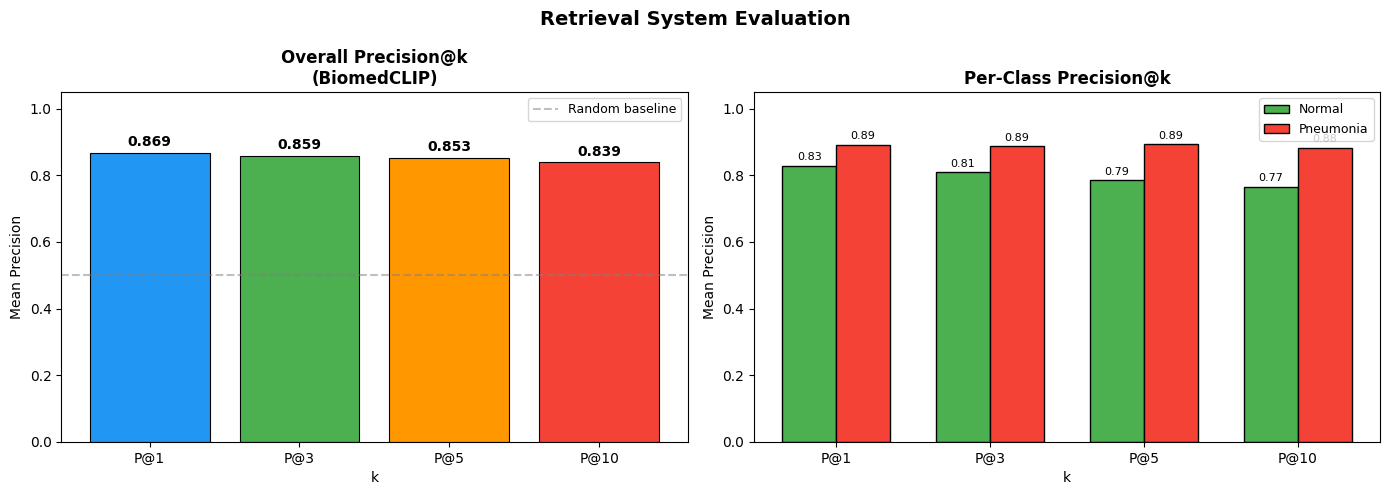

Precision@k chart saved.


In [16]:
# --- Plot Precision@k ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall Precision@k bar chart
k_labels = [f'P@{k}' for k in K_VALUES]
values   = [mean_prec[k] for k in K_VALUES]
bars = axes[0].bar(k_labels, values, color=['#2196F3','#4CAF50','#FF9800','#F44336'],
                   edgecolor='black', linewidth=0.8)
axes[0].set_ylim(0, 1.05)
axes[0].set_title(f'Overall Precision@k\n({MODEL_NAME})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Precision')
axes[0].set_xlabel('k')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].legend(fontsize=9)

# Right: Per-class Precision@k grouped bar chart
x = np.arange(len(K_VALUES))
width = 0.35
normal_vals   = [class_prec[k][0] for k in K_VALUES]
pneumonia_vals = [class_prec[k][1] for k in K_VALUES]

b1 = axes[1].bar(x - width/2, normal_vals,   width, label='Normal',    color='#4CAF50', edgecolor='black')
b2 = axes[1].bar(x + width/2, pneumonia_vals, width, label='Pneumonia', color='#F44336', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x)
axes[1].set_xticklabels(k_labels)
axes[1].set_title('Per-Class Precision@k', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Precision')
axes[1].set_xlabel('k')
axes[1].legend(fontsize=9)
for bar, val in zip(list(b1)+list(b2), normal_vals+pneumonia_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Retrieval System Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Precision@k chart saved.')

## Step 11: Embedding Space Visualization (t-SNE / UMAP)

Running t-SNE on test embeddings (this may take ~1-2 min)...


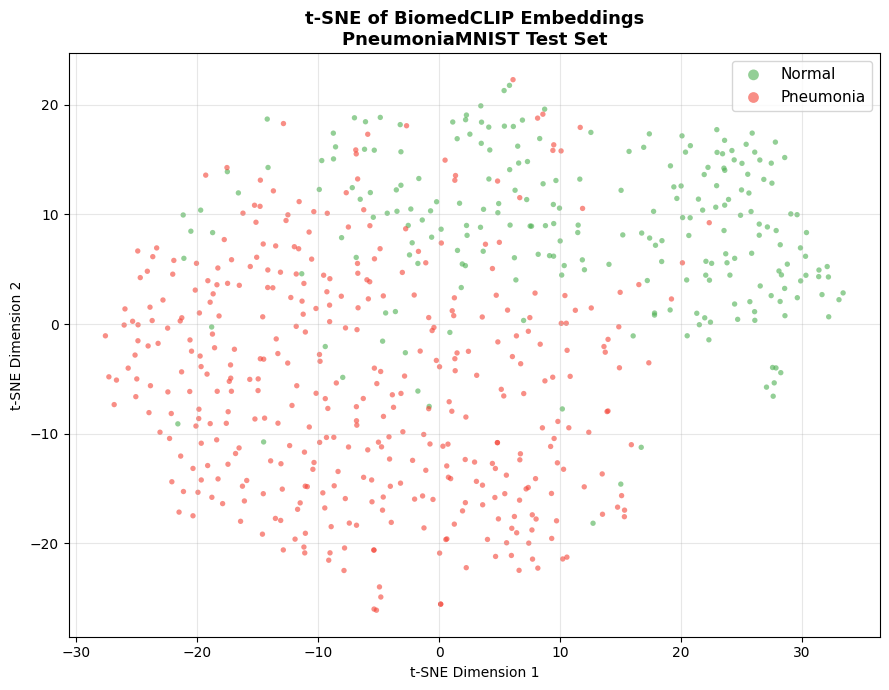

t-SNE visualization saved.


In [17]:
from sklearn.manifold import TSNE

print('Running t-SNE on test embeddings (this may take ~1-2 min)...')
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    verbose=0
)
tsne_embeds = tsne.fit_transform(test_embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
colors = {0: '#4CAF50', 1: '#F44336'}
for cls_idx, cls_name in LABEL_NAMES.items():
    mask = test_labels == cls_idx
    ax.scatter(
        tsne_embeds[mask, 0], tsne_embeds[mask, 1],
        c=colors[cls_idx], label=cls_name,
        alpha=0.6, s=15, edgecolors='none'
    )

ax.set_title(f't-SNE of {MODEL_NAME} Embeddings\nPneumoniaMNIST Test Set',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=11, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE visualization saved.')

## Step 12: Failure Case Analysis

Total test queries  : 624
Complete failures   : 12 (1.9%)
Perfect retrievals  : 388 (62.2%)

--- Failure Cases (Precision@5 = 0.0) ---


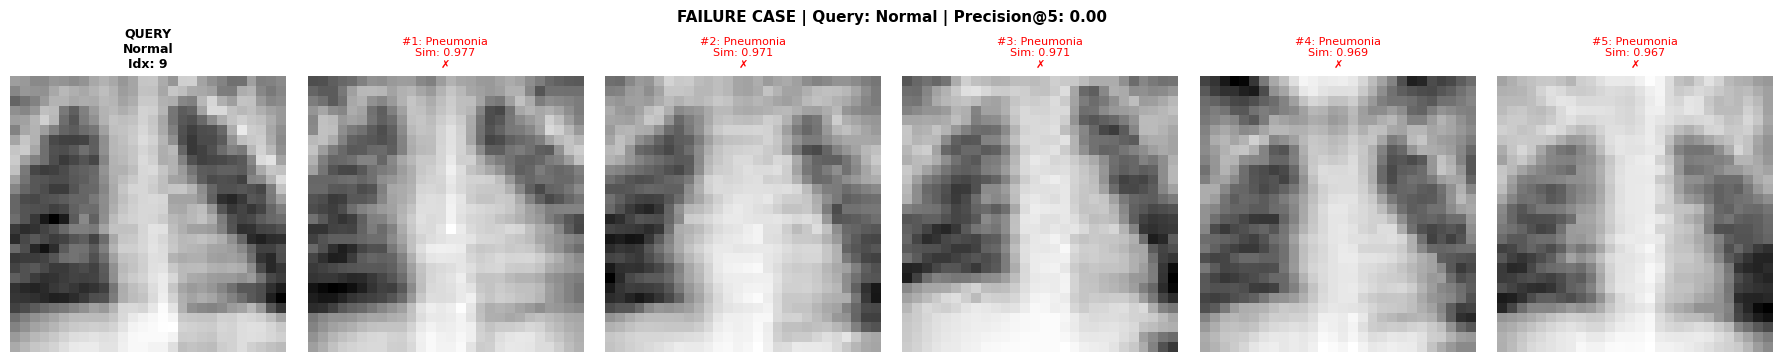

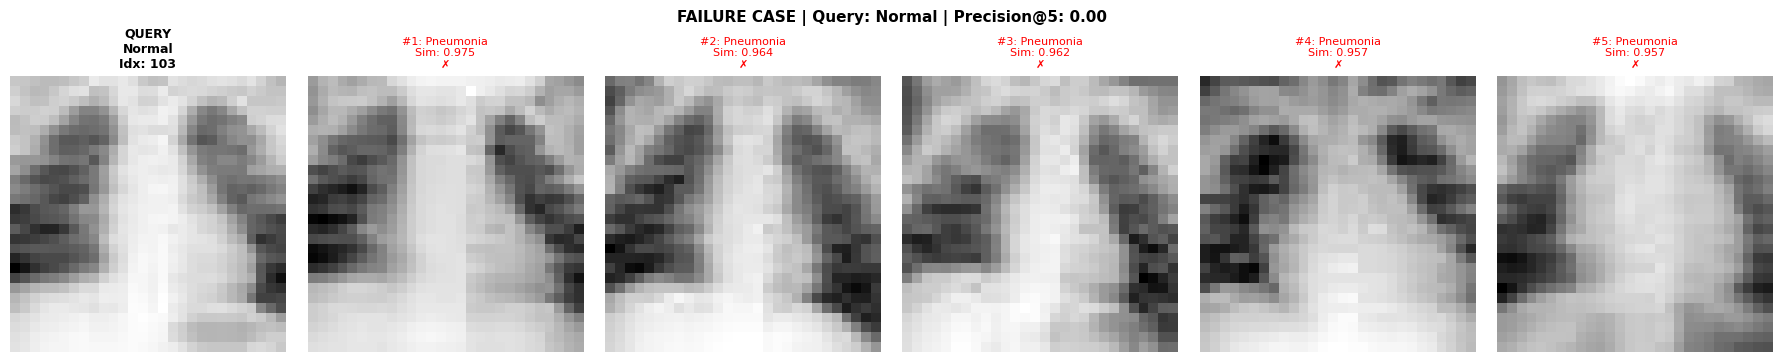

In [18]:
def find_failure_cases(embeddings, labels, index, k=5):
    """
    Find queries where Precision@k is 0 — complete retrieval failures.
    Also find best cases (Precision@k = 1.0).
    """
    _, all_indices = index.search(embeddings.astype('float32'), k + 1)

    failures = []
    successes = []

    for q_idx in range(len(embeddings)):
        q_label  = labels[q_idx]
        ret_idxs = all_indices[q_idx]
        ret_idxs = ret_idxs[ret_idxs != q_idx][:k]
        prec     = np.mean(labels[ret_idxs] == q_label)

        if prec == 0.0:
            failures.append((q_idx, prec, ret_idxs))
        elif prec == 1.0:
            successes.append((q_idx, prec, ret_idxs))

    return failures, successes


failures, successes = find_failure_cases(test_embeddings, test_labels, faiss_index, k=5)

print(f'Total test queries  : {len(test_embeddings)}')
print(f'Complete failures   : {len(failures)} ({100*len(failures)/len(test_embeddings):.1f}%)')
print(f'Perfect retrievals  : {len(successes)} ({100*len(successes)/len(test_embeddings):.1f}%)')

# Visualize up to 2 failures
if failures:
    print('\n--- Failure Cases (Precision@5 = 0.0) ---')
    for q_idx, prec, ret_idxs in failures[:2]:
        dists, _ = image_to_image_search(q_idx, faiss_index, test_embeddings, k=5)
        visualize_retrieval(
            q_idx, ret_idxs, dists, test_dataset, test_labels,
            title_prefix='FAILURE CASE',
            save_path=f'failure_case_{q_idx}.png'
        )
else:
    print('No complete failures found — excellent retrieval quality!')

## Step 13: Similarity Score Distribution

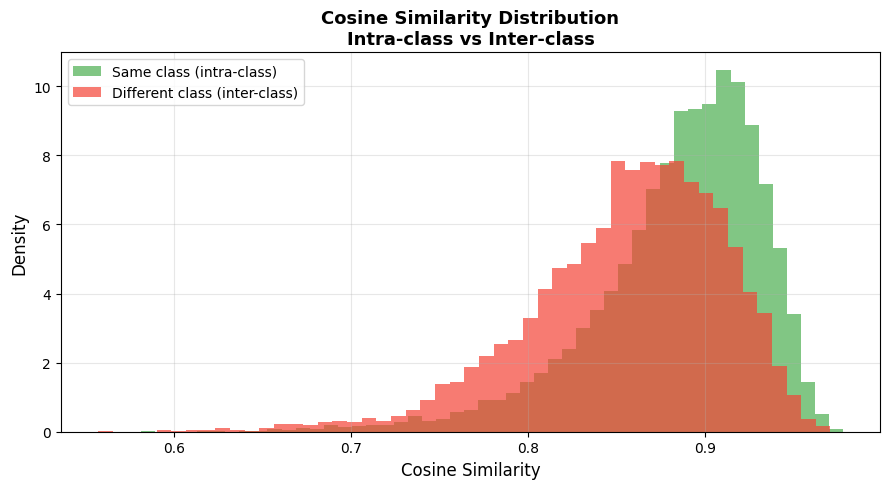

Mean intra-class similarity  : 0.8842
Mean inter-class similarity  : 0.8557
Separation (higher = better) : 0.0285


In [19]:
# Compute all pairwise similarities for a sample of 200 queries
sample_size = min(200, len(test_embeddings))
sample_idxs = np.random.choice(len(test_embeddings), sample_size, replace=False)
sample_embeds = test_embeddings[sample_idxs]
sample_labels = test_labels[sample_idxs]

# Similarity matrix
sim_matrix = sample_embeds @ sample_embeds.T

# Separate same-class vs cross-class similarities (excluding diagonal)
same_sims  = []
cross_sims = []
for i in range(sample_size):
    for j in range(i+1, sample_size):
        s = sim_matrix[i, j]
        if sample_labels[i] == sample_labels[j]:
            same_sims.append(s)
        else:
            cross_sims.append(s)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(same_sims,  bins=50, alpha=0.7, color='#4CAF50', label='Same class (intra-class)', density=True)
ax.hist(cross_sims, bins=50, alpha=0.7, color='#F44336', label='Different class (inter-class)', density=True)
ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Cosine Similarity Distribution\nIntra-class vs Inter-class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean intra-class similarity  : {np.mean(same_sims):.4f}')
print(f'Mean inter-class similarity  : {np.mean(cross_sims):.4f}')
print(f'Separation (higher = better) : {np.mean(same_sims) - np.mean(cross_sims):.4f}')

## Step 14: Command-Line Style Search Interface

In [20]:
class MedicalImageRetrievalSystem:
    """
    A clean interface for the semantic image retrieval system.
    Supports both image-to-image and text-to-image search.
    """

    def __init__(self, index, embeddings, labels, dataset, model, tokenizer, preprocess, device):
        self.index      = index
        self.embeddings = embeddings
        self.labels     = labels
        self.dataset    = dataset
        self.model      = model
        self.tokenizer  = tokenizer
        self.preprocess = preprocess
        self.device     = device

    def search_by_image_index(self, query_idx, k=5, visualize=True):
        """Search using an index into the test dataset."""
        distances, indices = image_to_image_search(
            query_idx, self.index, self.embeddings, k
        )
        if visualize:
            visualize_retrieval(
                query_idx, indices, distances,
                self.dataset, self.labels, 'Image-to-Image'
            )
        return indices, distances

    def search_by_pil_image(self, pil_image, k=5, visualize=True):
        """Search using an arbitrary PIL image."""
        img_rgb = pil_image.convert('RGB')
        tensor  = self.preprocess(img_rgb).unsqueeze(0).to(self.device)
        with torch.no_grad(), torch.cuda.amp.autocast():
            feat = self.model.encode_image(tensor)
            feat = feat / feat.norm(dim=-1, keepdim=True)
        query_vec = feat.cpu().float().numpy()
        distances, indices = self.index.search(query_vec.astype('float32'), k)
        if visualize:
            fig, axes = plt.subplots(1, k+1, figsize=(3*(k+1), 3.5))
            axes[0].imshow(pil_image, cmap='gray')
            axes[0].set_title('QUERY\n(External)', fontsize=9, fontweight='bold')
            axes[0].axis('off')
            for j, (idx, score) in enumerate(zip(indices[0], distances[0])):
                img, _ = self.dataset[idx]
                axes[j+1].imshow(img, cmap='gray')
                axes[j+1].set_title(f'#{j+1}: {LABEL_NAMES[self.labels[idx]]}\nSim:{score:.3f}', fontsize=8)
                axes[j+1].axis('off')
            plt.suptitle('Search by External Image', fontweight='bold')
            plt.tight_layout()
            plt.show()
        return indices[0], distances[0]

    def search_by_text(self, text_query, k=5, visualize=True):
        """Search using a natural language text query."""
        distances, indices = text_to_image_search(
            text_query, self.model, self.tokenizer, self.index, k, self.device
        )
        if visualize:
            visualize_text_retrieval(
                text_query, indices, distances, self.dataset, self.labels
            )
        return indices, distances

    def info(self):
        print(f'Retrieval System Info')
        print(f'  Indexed images  : {self.index.ntotal}')
        print(f'  Embedding dim   : {self.index.d}')
        print(f'  Index type      : {type(self.index).__name__}')
        for cls_idx, cls_name in LABEL_NAMES.items():
            count = int(np.sum(self.labels == cls_idx))
            print(f'  {cls_name:<12} : {count} images')


# Instantiate the system
retrieval_system = MedicalImageRetrievalSystem(
    index=faiss_index,
    embeddings=test_embeddings,
    labels=test_labels,
    dataset=test_dataset,
    model=model,
    tokenizer=tokenizer,
    preprocess=preprocess,
    device=DEVICE
)

retrieval_system.info()

Retrieval System Info
  Indexed images  : 624
  Embedding dim   : 512
  Index type      : IndexFlatIP
  Normal       : 234 images
  Pneumonia    : 390 images


--- Image-to-Image Search ---


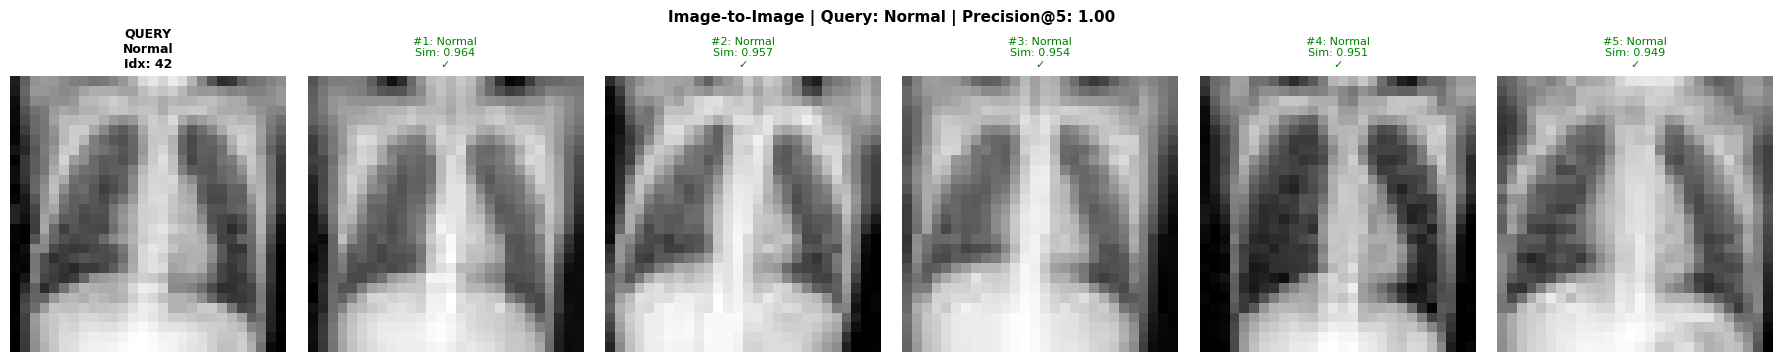


--- Text-to-Image Search ---


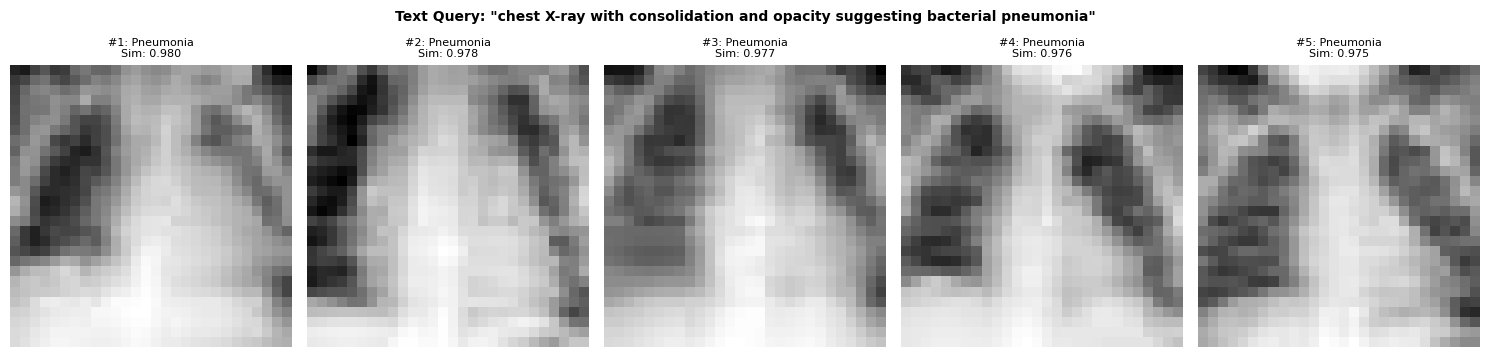

(array([155, 550, 124, 576, 605]),
 array([0.9801563, 0.9778564, 0.9772927, 0.9763236, 0.974926 ],
       dtype=float32))

In [21]:
# ========== INTERACTIVE DEMO ==========
# Try your own queries here!

# Image-to-image search by index
print('--- Image-to-Image Search ---')
retrieval_system.search_by_image_index(query_idx=42, k=5)

# Text-to-image search
print('\n--- Text-to-Image Search ---')
retrieval_system.search_by_text(
    text_query="chest X-ray with consolidation and opacity suggesting bacterial pneumonia",
    k=5
)

## Step 15: Save & Load Index (Persistence)

In [22]:
# Demonstrate saving and reloading the index
print('Saving index and embeddings...')
faiss.write_index(faiss_index, INDEX_PATH)
np.savez(EMBED_PATH, embeddings=test_embeddings, labels=test_labels)

# Reload to verify
loaded_index = faiss.read_index(INDEX_PATH)
loaded_data  = np.load(EMBED_PATH)

print(f'Loaded index vectors : {loaded_index.ntotal}')
print(f'Loaded embeddings    : {loaded_data["embeddings"].shape}')
print(f'Loaded labels        : {loaded_data["labels"].shape}')
print('Index persistence verified!')

# List all saved artifacts
import glob
print('\nSaved files:')
for f in sorted(glob.glob('*.png') + glob.glob('*.bin') + glob.glob('*.npz')):
    size = os.path.getsize(f) / 1024
    print(f'  {f:<45} ({size:.1f} KB)')

Saving index and embeddings...
Loaded index vectors : 624
Loaded embeddings    : (624, 512)
Loaded labels        : (624,)
Index persistence verified!

Saved files:
  embeddings.npz                                (1253.4 KB)
  failure_case_103.png                          (44.9 KB)
  failure_case_9.png                            (44.5 KB)
  faiss_index.bin                               (1248.0 KB)
  precision_at_k.png                            (67.8 KB)
  retrieval_img2img_query0.png                  (47.1 KB)
  retrieval_img2img_query1.png                  (49.0 KB)
  retrieval_img2img_query25.png                 (45.6 KB)
  retrieval_img2img_query7.png                  (45.9 KB)
  sample_images.png                             (40.3 KB)
  similarity_distribution.png                   (42.8 KB)
  tsne_embeddings.png                           (150.3 KB)


## Step 16: Final Summary Report

In [27]:
print('='*65)
print('  TASK 3: SEMANTIC IMAGE RETRIEVAL — FINAL SUMMARY')
print('='*65)
print(f'  Dataset         : PneumoniaMNIST (test set, {len(test_dataset)} images)')
print(f'  Embedding Model : {MODEL_NAME}')
print(f'  Vector Database : FAISS IndexFlatIP (exact cosine similarity)')
print(f'  Embedding Dim   : {test_embeddings.shape[1]}')
print(f'  Device          : {DEVICE}')
print()
print('  Retrieval Performance (Precision@k):')
for k in K_VALUES:
    print(f'    P@{k:<4}: {mean_prec[k]:.4f}  '
          f'(Normal: {class_prec[k][0]:.4f}, Pneumonia: {class_prec[k][1]:.4f})')
print()
print('  Capabilities:')
print('    [✓] Image-to-image search')
print('    [✓] Text-to-image search')
print('    [✓] Index persistence (save/load)')
print('    [✓] Embedding space visualization (t-SNE)')
print('    [✓] Failure case analysis')
print('    [✓] Similarity distribution analysis')
print('='*65)

  TASK 3: SEMANTIC IMAGE RETRIEVAL — FINAL SUMMARY
  Dataset         : PneumoniaMNIST (test set, 624 images)
  Embedding Model : BiomedCLIP
  Vector Database : FAISS IndexFlatIP (exact cosine similarity)
  Embedding Dim   : 512
  Device          : cuda

  Retrieval Performance (Precision@k):
    P@1   : 0.8686  (Normal: 0.8291, Pneumonia: 0.8923)
    P@3   : 0.8590  (Normal: 0.8105, Pneumonia: 0.8880)
    P@5   : 0.8529  (Normal: 0.7863, Pneumonia: 0.8928)
    P@10  : 0.8391  (Normal: 0.7658, Pneumonia: 0.8831)

  Capabilities:
    [✓] Image-to-image search
    [✓] Text-to-image search
    [✓] Index persistence (save/load)
    [✓] Embedding space visualization (t-SNE)
    [✓] Failure case analysis
    [✓] Similarity distribution analysis
